In [1]:
#Install Required Libraries
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.7 MB/s eta 0:00:00


In [2]:
#Import Libraries

from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
from google.colab import files

import os, glob, yaml
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully.


In [3]:
#Connect Roboflow Dataset
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yhRhGK4YwblZVz28vkBy")
project = rf.workspace("md-nawshin-navin").project("eye-disease-jio2h")
version = project.version(5)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Eye-Disease-5 in yolov8:: 100%|██████████| 11232/11232 [00:01<00:00, 7350.47it/s]


In [4]:
# Check Dataset Files

dataset_path = dataset.location
data_yaml_path = os.path.join(dataset_path, "data.yaml")

print("Dataset path:", dataset_path)
print("data.yaml exists:", os.path.exists(data_yaml_path))

print("\nDataset folder content:")
for item in os.listdir(dataset_path):
    print("-", item)

Dataset path: /content/Eye-Disease-5
data.yaml exists: True

Dataset folder content:
- test
- README.dataset.txt
- data.yaml
- README.roboflow.txt
- valid
- train


In [5]:
# Read data.yaml and Class Names
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

class_names = data_yaml.get("names", [])
print("\nClasses:", class_names)
print("Number of classes:", len(class_names))

{'names': ['Cataract', 'Jaundice', 'Normal_Eye', 'Pterygium'], 'nc': 4, 'roboflow': {'license': 'CC BY 4.0', 'project': 'eye-disease-jio2h', 'url': 'https://universe.roboflow.com/md-nawshin-navin/eye-disease-jio2h/dataset/5', 'version': 5, 'workspace': 'md-nawshin-navin'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Classes: ['Cataract', 'Jaundice', 'Normal_Eye', 'Pterygium']
Number of classes: 4


In [6]:
#Count Images in Train, Validation, and Test Sets
def count_images(folder):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    return sum(len(glob.glob(os.path.join(folder, ext))) for ext in exts)

train_img_dir = os.path.join(dataset_path, "train", "images")
valid_img_dir = os.path.join(dataset_path, "valid", "images")
test_img_dir = os.path.join(dataset_path, "test", "images")

counts = {
    "Train Images": count_images(train_img_dir),
    "Validation Images": count_images(valid_img_dir),
    "Test Images": count_images(test_img_dir)
}

pd.DataFrame([counts])

,Train Images,Validation Images,Test Images
0,3988,811,811


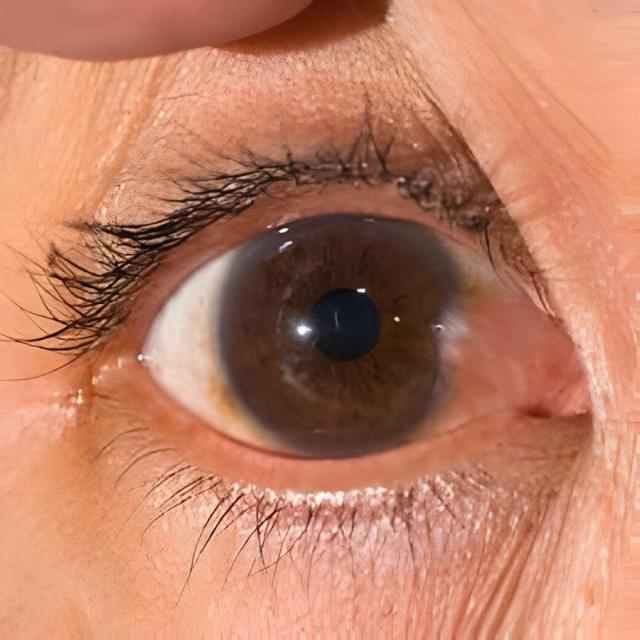

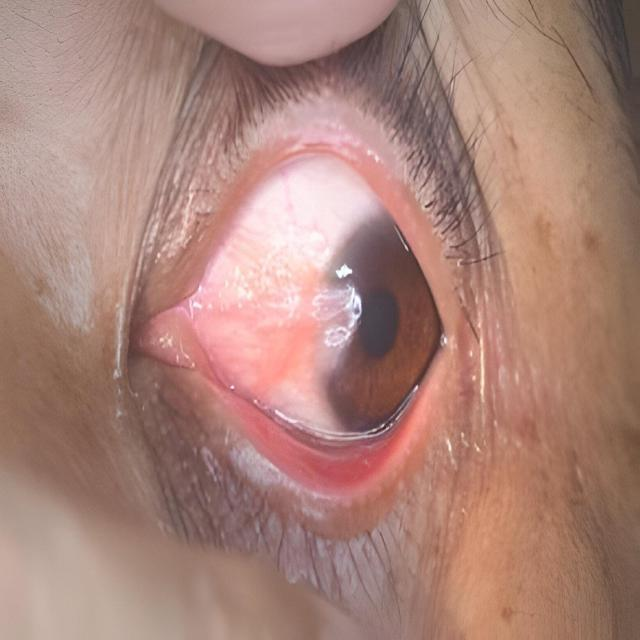

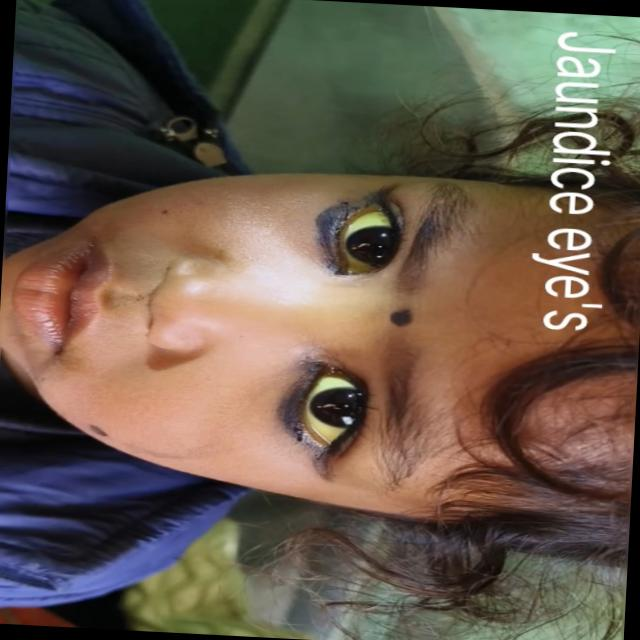

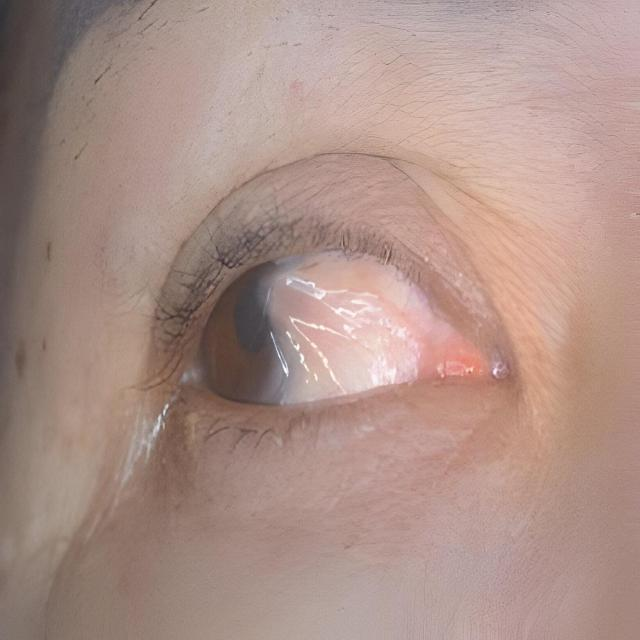

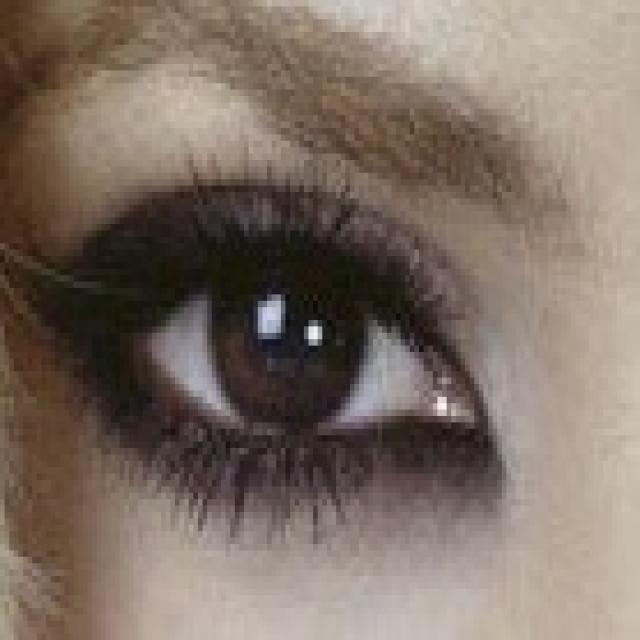

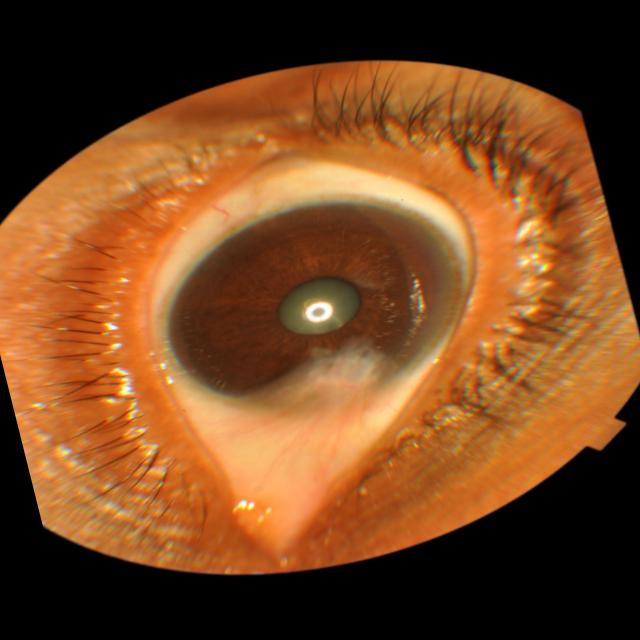

In [7]:
#Preview Sample Training Images
sample_images = glob.glob(os.path.join(train_img_dir, "*"))[:6]

for img in sample_images:
    display(Image(filename=img, width=400))



In [8]:
#Load Pretrained YOLO Model
model = YOLO("yolov8n.pt")
print("YOLOv8 nano model loaded successfully.")


YOLOv8 nano model loaded successfully.


In [9]:
#Eye Disease Detection Model

results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=640,
    batch=8,
    name="Eye_Disease_detection_Model_yolov8_roboflow"
)


Ultralytics 8.4.79 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Eye-Disease-5/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Eye_Disease_detection_Model_yolov8_roboflow, nbs=64, nms=False, opset=


 results.png


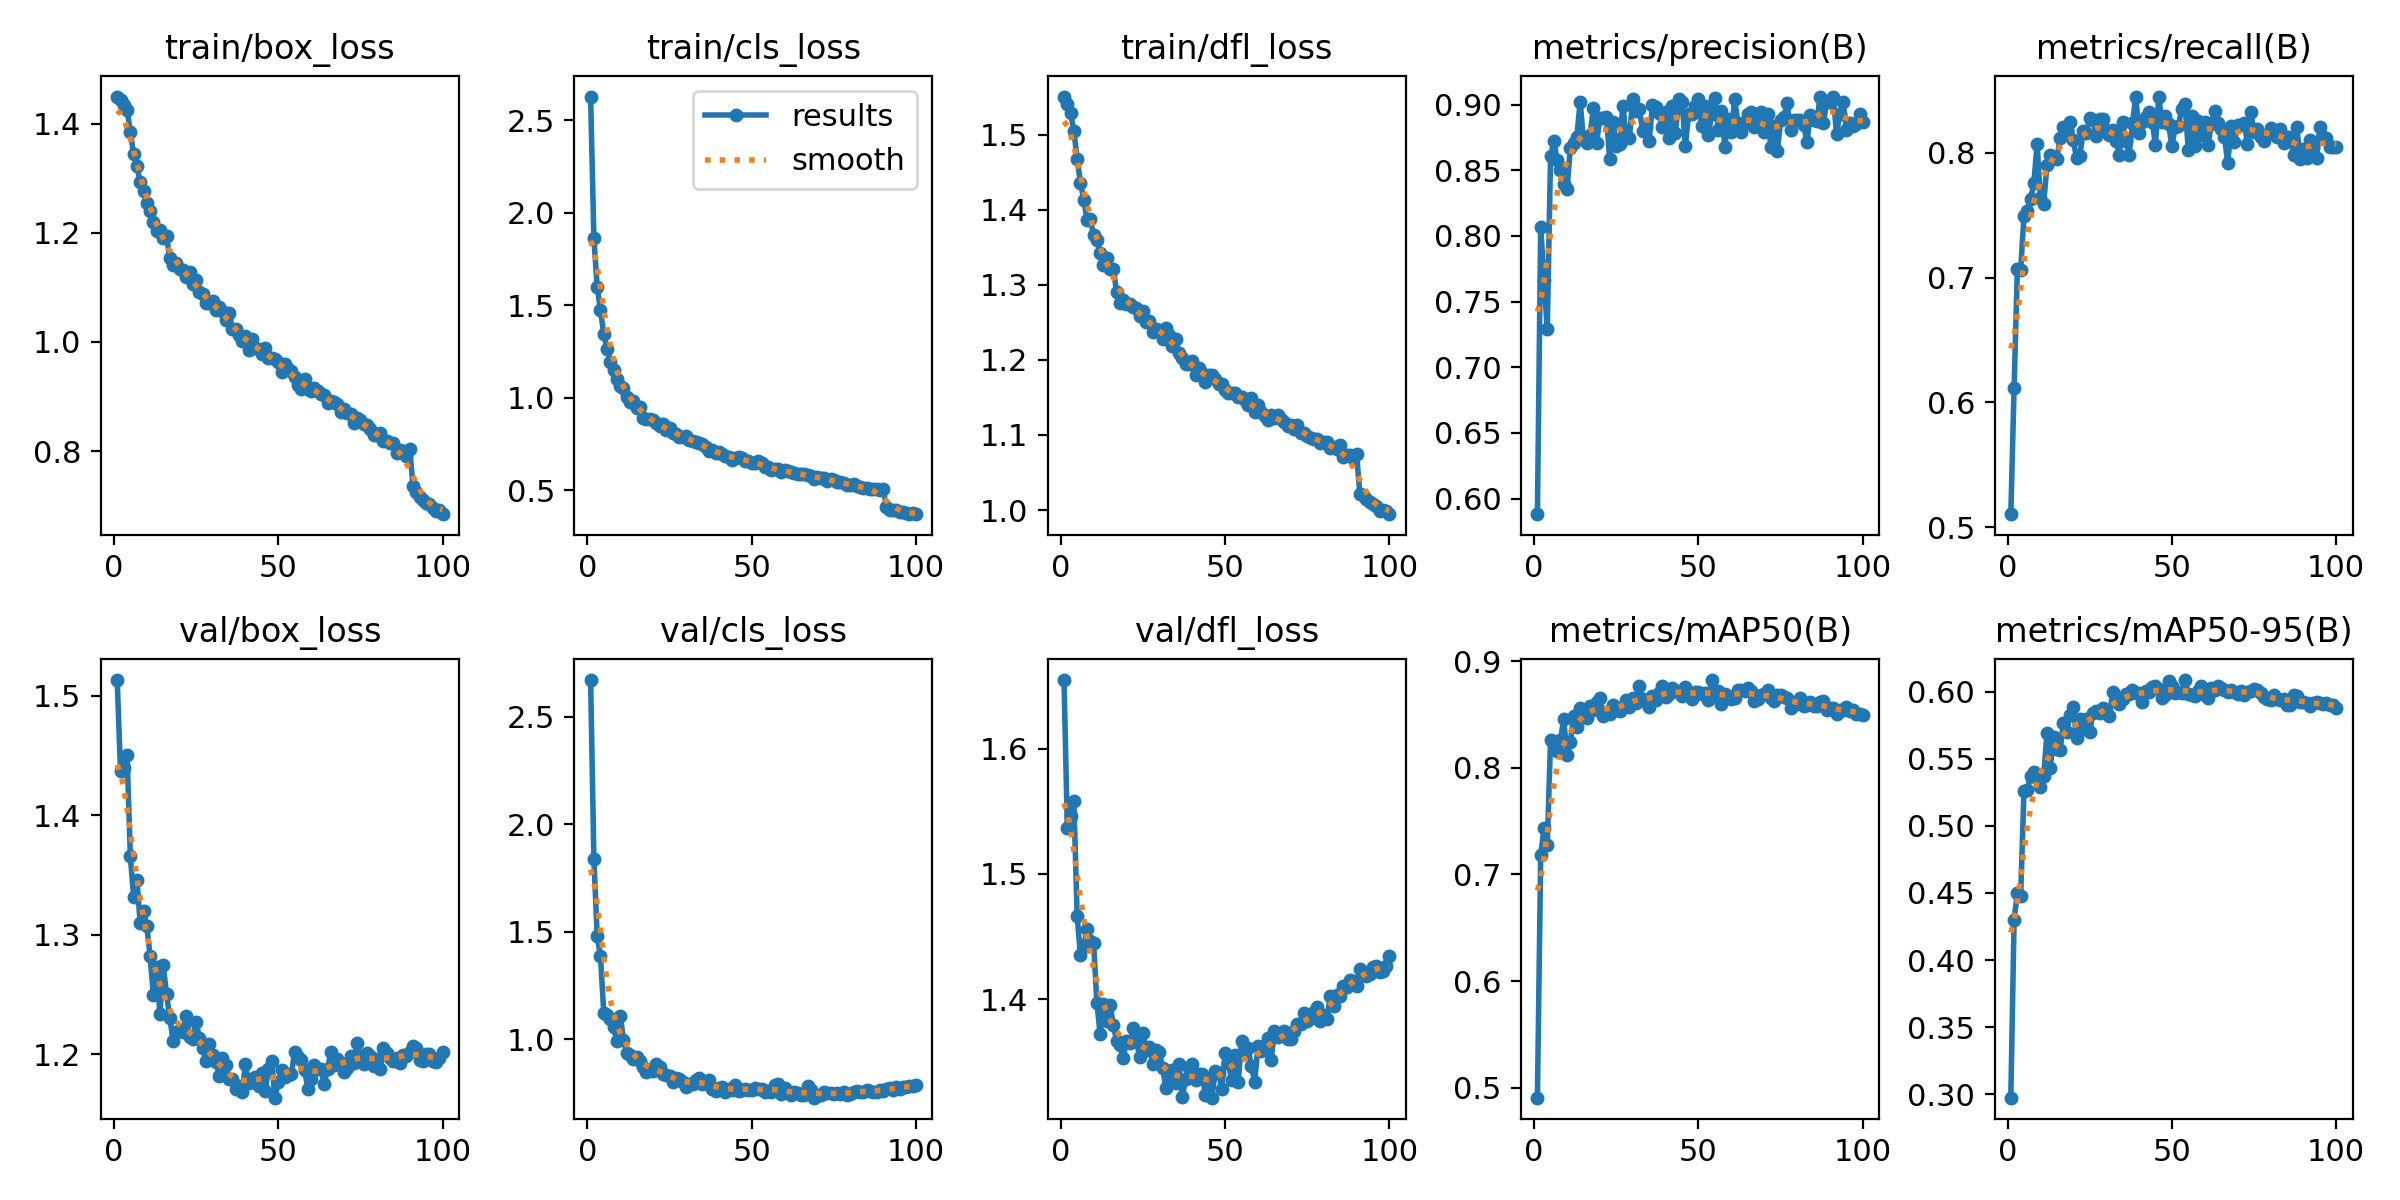


 confusion_matrix.png


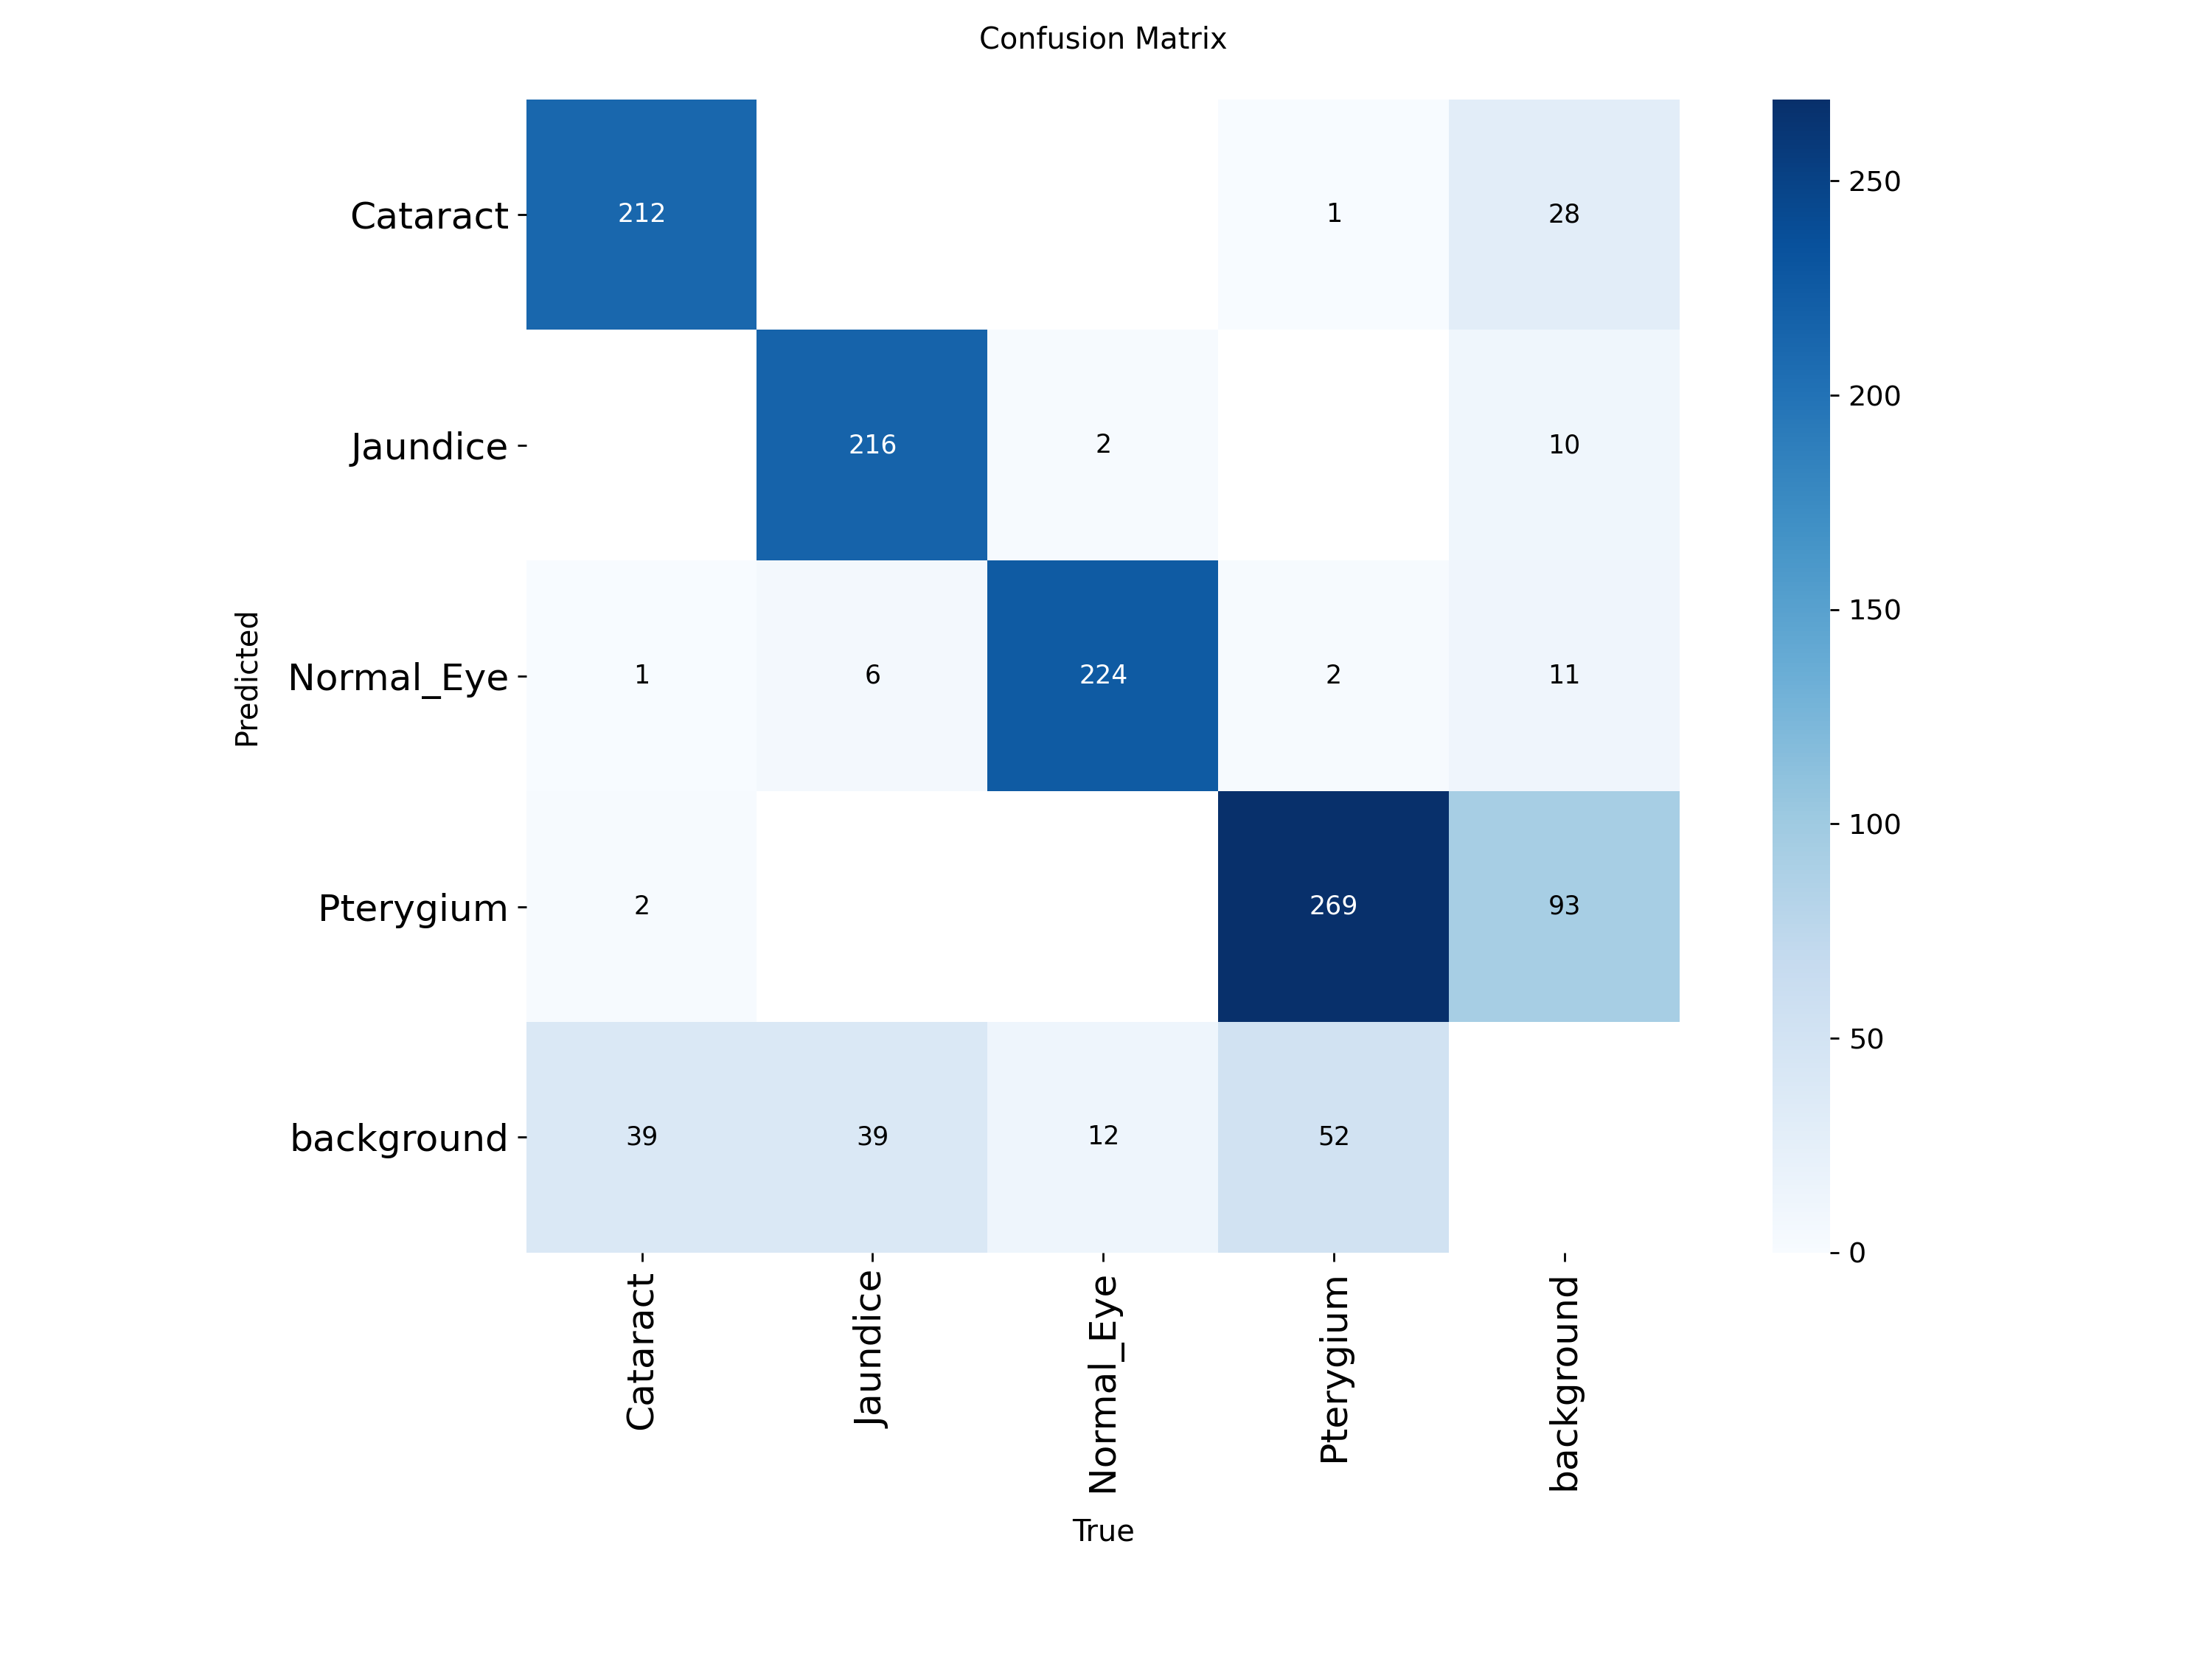

Not found: PR_curve.png
Not found: F1_curve.png
Not found: P_curve.png
Not found: R_curve.png


In [10]:
#Display Training Results
train_run_dir = "runs/detect/Eye_Disease_detection_Model_yolov8_roboflow"

result_files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for file in result_files:
    path = os.path.join(train_run_dir, file)
    if os.path.exists(path):
        print("\n", file)
        display(Image(filename=path, width=800))
    else:
        print("Not found:", file)


In [11]:
#Validate the Trained Model

best_model_path = os.path.join(train_run_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

metrics = best_model.val(data=data_yaml_path)

print("Validation completed.")

Ultralytics 8.4.79 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1285.4±592.8 MB/s, size: 37.7 KB)
val: Scanning /content/Eye-Disease-5/valid/labels.cache... 811 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 811/811 340.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1000, len(boxes) = 1077. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 5.8it/s 8.7s
                   all        811       1077      0.893      0.839      0.882      0.607
              Cataract        253        254      0.909      0.831      0.872      0.684
              Jaundice        167  

In [12]:
from ultralytics import YOLO
import glob
import os

# Find trained YOLO model automatically
model_files = glob.glob(
    "runs/detect/**/weights/best.pt",
    recursive=True
)

if len(model_files) == 0:
    print("No trained model found. Train the model first.")
else:

    best_model_path = model_files[0]

    print("Loading model:")
    print(best_model_path)

    best_model = YOLO(best_model_path)

    # Validate model
    metrics = best_model.val(
        data=data_yaml_path
    )

    print("Validation completed.")

Loading model:
runs/detect/Eye_Disease_detection_Model_yolov8_roboflow/weights/best.pt
Ultralytics 8.4.79 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 755.3±370.9 MB/s, size: 38.7 KB)
val: Scanning /content/Eye-Disease-5/valid/labels.cache... 811 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 811/811 283.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1000, len(boxes) = 1077. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 5.6it/s 9.2s
                   all        811       1077      0.893      0.839      0.882      0.607
              Cataract        253     

In [13]:
test_results = best_model.predict(
    source=test_img_dir,
    conf=0.4,
    save=True,
    name="eye_disease_detection"
)

print("Prediction completed on test images.")


image 1/811 /content/Eye-Disease-5/test/images/-jaundice-medicalshort_mp4-0003_jpg.rf.3a8d6452f4f1a5d7d48a8c94a3032ced.jpg: 640x640 2 Jaundices, 8.4ms
image 2/811 /content/Eye-Disease-5/test/images/-jaundice-medicalshort_mp4-0007_jpg.rf.052d5ee928c36e48d2b67a90e0b1f1f1.jpg: 640x640 2 Jaundices, 7.3ms
image 3/811 /content/Eye-Disease-5/test/images/-jaundice-medicalshort_mp4-0009_jpg.rf.8b1e4fefd6846b94bb27a5cf055cdfe7.jpg: 640x640 2 Jaundices, 7.2ms
image 4/811 /content/Eye-Disease-5/test/images/-jaundice-medicalshort_mp4-0010_jpg.rf.9ef4f27c27f1e0a16e1a3f4700d0a881.jpg: 640x640 2 Jaundices, 7.2ms
image 5/811 /content/Eye-Disease-5/test/images/-jaundice-medicalshort_mp4-0013_jpg.rf.c9fdf8830ee6b53d232e463349394cc3.jpg: 640x640 2 Jaundices, 7.5ms
image 6/811 /content/Eye-Disease-5/test/images/-jaundice-medicalshort_mp4-0014_jpg.rf.09c9249d4ee3c3b92605079ed0134283.jpg: 640x640 2 Jaundices, 7.2ms
image 7/811 /content/Eye-Disease-5/test/images/-jaundice-medicalshort_mp4-0018_jpg.rf.39a0fc5

In [14]:
import os
import glob
from IPython.display import Image, display

# Path where YOLO saved predictions
prediction_dir = "runs/detect/eye_disease_detection-2"

# Get only image files
predicted_images = []

for ext in ["*.jpg", "*.jpeg", "*.png"]:
    predicted_images.extend(
        glob.glob(os.path.join(prediction_dir, ext))
    )

print("Number of predicted images:", len(predicted_images))

# Display first 10 predicted images
for img in predicted_images[:10]:
    display(Image(filename=img, width=600))

Number of predicted images: 0


In [23]:
uploaded = files.upload()
uploaded_image = list(uploaded.keys())[0]

results = best_model.predict(
    source=uploaded_image,
    conf=0.25,
    iou=0.4,  # Try lowering this (default is 0.7). Lower = fewer overlapping boxes.
    save=True,
    name="eye_disease_detection"
)


Saving catract eye.jpg to catract eye.jpg

image 1/1 /content/catract eye.jpg: 448x640 1 Cataract, 1 Normal_Eye, 48.7ms
Speed: 3.8ms preprocess, 48.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/eye_disease_detection-5


Using latest result folder: runs/detect/eye_disease_detection-5


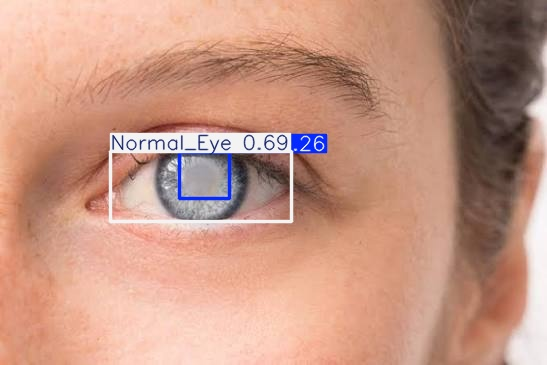

In [24]:
import os
import glob
from IPython.display import Image, display

# 1. Define the base directory where YOLO saves results
base_dir = "runs/detect"

# 2. Find all folders that match the pattern "eye_disease_detection*"
# We use glob to get all subfolders starting with your name
prediction_dirs = glob.glob(os.path.join(base_dir, "eye_disease_detection*"))

# 3. Sort the folders by creation time (or name) to get the most recent one
# Using max() with os.path.getmtime finds the folder modified most recently
latest_dir = max(prediction_dirs, key=os.path.getmtime)

print(f"Using latest result folder: {latest_dir}")

# 4. Grab the images from that folder
uploaded_pred_images = glob.glob(os.path.join(latest_dir, "*"))

for img in uploaded_pred_images:
    display(Image(filename=img, width=700))

In [25]:
# Update your prediction call to be more lenient
single_result = best_model.predict(
    source=uploaded_image,
    conf=0.25,  # Lowered to 0.25 to capture the 0.32 detection
    save=True,
    name="eye_disease_detection"
)

# Now your existing detection logic will work:
detections = []
for result in single_result:
    names = result.names
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = names[cls_id]

        detections.append({
            "Detected Object": label,
            "Confidence Score": round(conf, 3)
        })

if len(detections) == 0:
    print("No Disease Detected.")
else:
    import pandas as pd
    display(pd.DataFrame(detections))


image 1/1 /content/catract eye.jpg: 448x640 1 Cataract, 1 Normal_Eye, 8.2ms
Speed: 2.5ms preprocess, 8.2ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/eye_disease_detection-6


,Detected Object,Confidence Score
0,Normal_Eye,0.690
1,Cataract,0.257


In [26]:
import os

# List all contents in the 'runs' folder to find the actual path
import glob
print(glob.glob('runs/**/*best.pt', recursive=True))

['runs/detect/Eye_Disease_detection_Model_yolov8_roboflow/weights/best.pt']
